# Assignment 4


**Student Name:** Sheylle Green and Marc Wijnands 

**Group Number:** 20

In [44]:
import diplib as dip
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Part 1

### Question 1: Segmentation of 15 cells in the Control Series (frame 0)


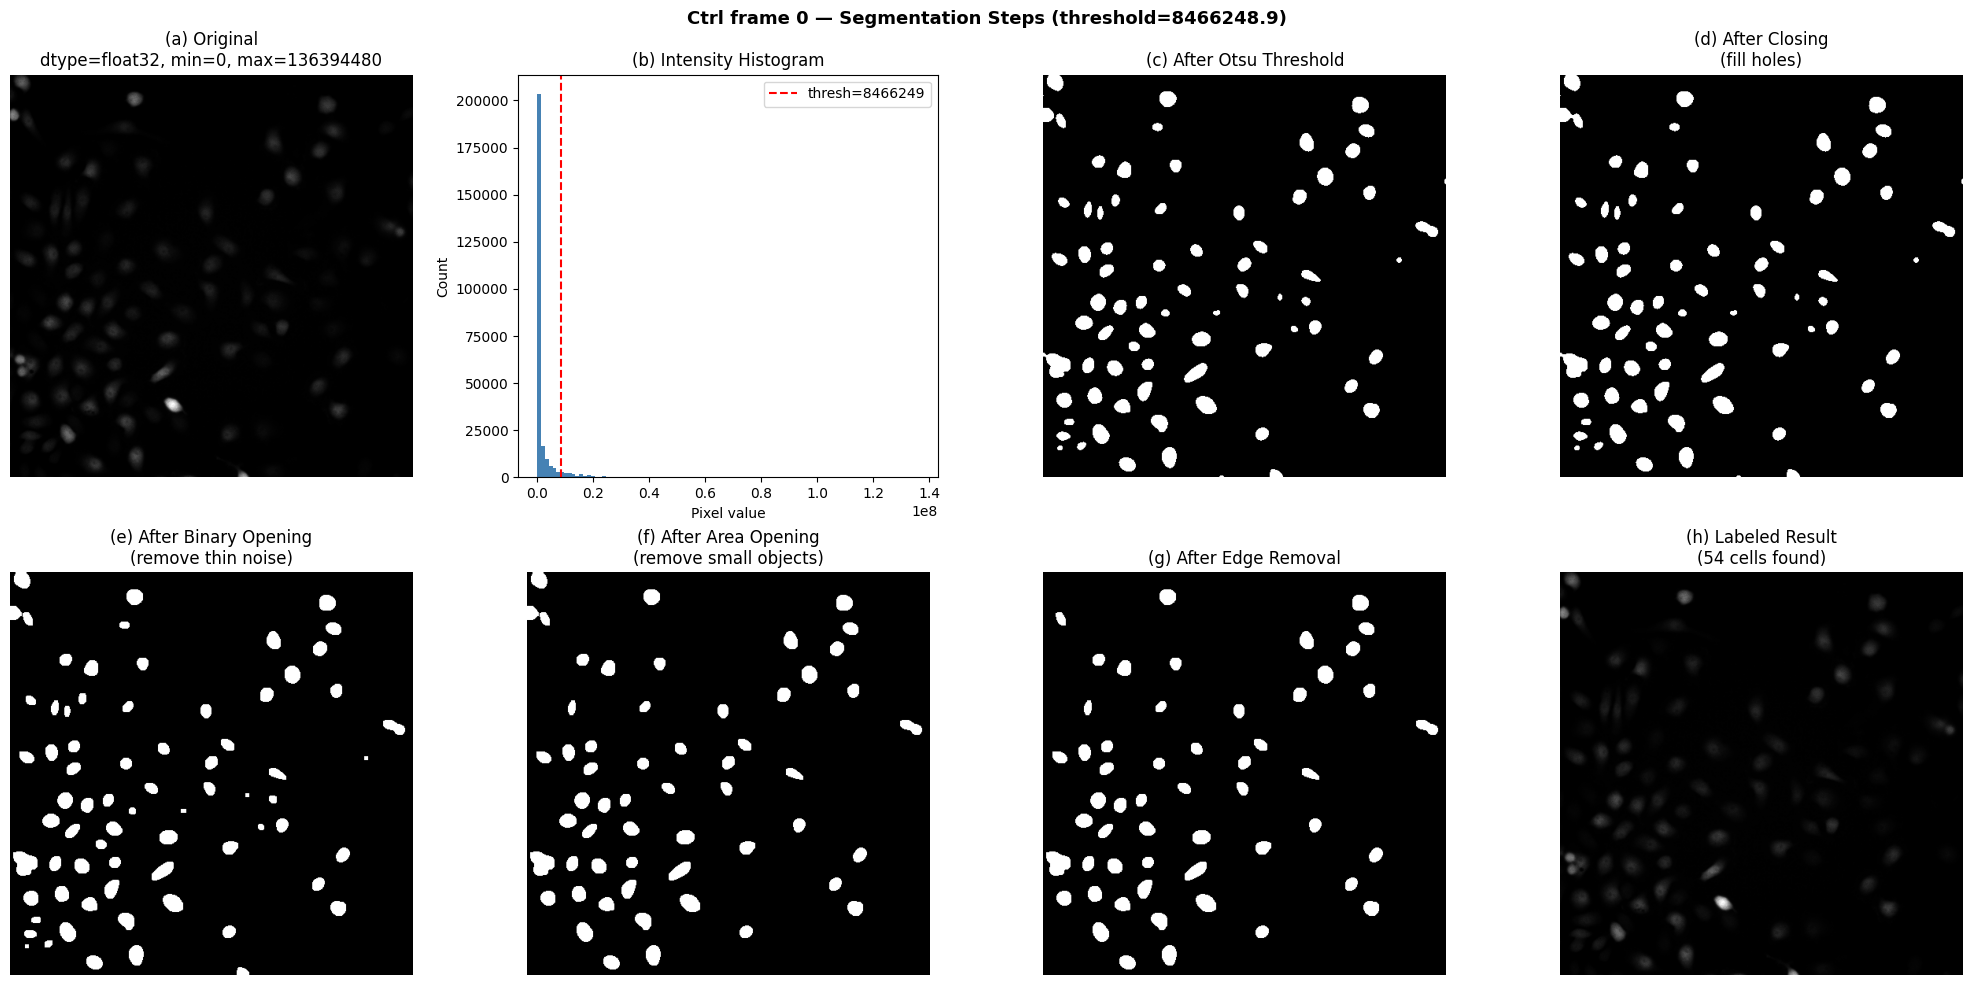

Otsu threshold : 8466248.9
Total cells found: 54
Image dtype : float32
Intensity range: 0 – 136394480


In [45]:
def segment_cells(filepath, plot=False, imgname='frame'):
    img = dip.ImageReadTIFF(filepath)

    if img.TensorElements() > 1:
        img = dip.ColorSpaceManager.Convert(img, 'gray')

    arr_orig = np.array(img)

    #Smooth
    smoothed = dip.Gauss(img, [2])
    # Otsu threshold
    binary, thresh_val = dip.Threshold(smoothed)
    thresh_val = float(thresh_val)
    # Close holes
    closed = dip.Closing(binary, dip.SE(5, 'elliptic')) ## Maybe try rectangular instead
    #Binary opening
    opened = dip.BinaryOpening(closed, connectivity=2, iterations=2)
    # Remove small objects
    area_opened = dip.AreaOpening(opened, filterSize=150)
    # Remove border cells
    no_border = dip.EdgeObjectsRemove(area_opened)
    # Label
    labeled = dip.Label(no_border, connectivity=2)
    label_arr = np.array(labeled)

    if plot:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        fig.suptitle(f'{imgname} — Segmentation Steps (threshold={thresh_val:.1f})',
                     fontsize=13, fontweight='bold')

        # (a) Original
        axes[0,0].imshow(arr_orig, cmap='gray')
        axes[0,0].set_title(f'(a) Original\ndtype={arr_orig.dtype}, '
                            f'min={arr_orig.min():.0f}, max={arr_orig.max():.0f}')
        axes[0,0].axis('off')

        # (b) Histogram
        axes[0,1].hist(arr_orig.ravel(), bins=100, color='steelblue')
        axes[0,1].axvline(thresh_val, color='red', linestyle='--',
                          label=f'thresh={thresh_val:.0f}')
        axes[0,1].set_title('(b) Intensity Histogram')
        axes[0,1].set_xlabel('Pixel value')
        axes[0,1].set_ylabel('Count')
        axes[0,1].legend()

        # (c) After Otsu
        axes[0,2].imshow(np.array(binary), cmap='gray')
        axes[0,2].set_title('(c) After Otsu Threshold')
        axes[0,2].axis('off')

        # (d) After closing
        axes[0,3].imshow(np.array(closed), cmap='gray')
        axes[0,3].set_title('(d) After Closing\n(fill holes)')
        axes[0,3].axis('off')

        # (e) After binary opening
        axes[1,0].imshow(np.array(opened), cmap='gray')
        axes[1,0].set_title('(e) After Binary Opening\n(remove thin noise)')
        axes[1,0].axis('off')

        # (f) After area opening
        axes[1,1].imshow(np.array(area_opened), cmap='gray')
        axes[1,1].set_title('(f) After Area Opening\n(remove small objects)')
        axes[1,1].axis('off')

        # (g) After edge removal
        axes[1,2].imshow(np.array(no_border), cmap='gray')
        axes[1,2].set_title('(g) After Edge Removal')
        axes[1,2].axis('off')

        # (h) Labeled overlay — use MeasurementTool then Measure
        mt = dip.MeasurementTool
        msr = mt.Measure(labeled, img, ['Center', 'Size'])

        axes[1,3].imshow(arr_orig, cmap='gray')
        for obj in msr.Objects():
            cx = msr[obj]['Center'][0]
            cy = msr[obj]['Center'][1]
            axes[1,3].text(cx, cy, str(obj), color='red', fontsize=7,
                           fontweight='bold', ha='center', va='center',
                           bbox=dict(boxstyle='round,pad=0.15', fc='yellow', alpha=0.6))
        axes[1,3].set_title(f'(h) Labeled Result\n({int(label_arr.max())} cells found)')
        axes[1,3].axis('off')

        plt.tight_layout()
        plt.show()

    return img, no_border, labeled, thresh_val


# Run with plots on frame 0
img0, binary0, labeled0, thresh0 = segment_cells(
    'MTLn3-ctrl0000.tif', plot=True, imgname='Ctrl frame 0'
)
arr0 = np.array(img0)
label_arr = np.array(labeled0)

print(f'Otsu threshold : {thresh0:.1f}')
print(f'Total cells found: {int(label_arr.max())}')
print(f'Image dtype : {arr0.dtype}')
print(f'Intensity range: {arr0.min():.0f} – {arr0.max():.0f}')

### Question 2: Tracking algorithm

 **Criterion:** Nearest-centroid matching.
 For each chosen cell in frame t, find the cell in frame t+1 whose centroid is
 closest (Euclidean distance) to the centroid in frame t, within a max search
 radius (max_dist). If no cell falls within that radius the cell is considered
 lost and its last known position is kept as a placeholder.

 This criterion is valid because:
 - Cells move slowly relative to the frame interval (2 min), so large jumps are unlikely.
 - The search radius limits false matches to distant, unrelated cells.

In [46]:
## COULD BE A PROBLEM: i didn't use diplib because i kept getting and inf bug
def get_centroids(labeled_img, grey_img):
    label_arr = np.array(labeled_img)
    obj_ids   = [i for i in np.unique(label_arr) if i > 0]  # skip background (0)
    
    cells = []
    for obj_id in obj_ids:
        mask = (label_arr == obj_id)
        size = float(mask.sum())
        # centroid: mean of row/col indices where mask is True
        rows, cols = np.where(mask)
        cx = float(cols.mean())  # x = column
        cy = float(rows.mean())  # y = row
        single_cell = (mask * grey_img)
        cells.append({'id': int(obj_id), 'cx': cx, 'cy': cy, 'size': size, 'single_cell': single_cell})
    
    return cells

def stretch(arr):
    a, b = arr.min(), arr.max()
    return (arr - a) / (b - a) if b > a else arr

Cells detected in frame 0: 54
Size range: 153 – 696px
Median size: 260px
Candidates after size filter: 43
Cell  1: label=22, center=(255.4, 241.7), size=223px
Cell  2: label=54, center=(106.8, 495.5), size=302px
Cell  3: label=2, center=(402.5, 38.8), size=358px
Cell  4: label=49, center=(416.7, 426.7), size=312px
Cell  5: label=21, center=(20.8, 234.9), size=231px
Cell  6: label=1, center=(158.0, 31.2), size=349px
Cell  7: label=16, center=(487.8, 196.5), size=334px
Cell  8: label=42, center=(193.8, 379.5), size=413px
Cell  9: label=39, center=(57.1, 369.9), size=238px
Cell 10: label=32, center=(345.2, 321.2), size=226px
Cell 11: label=7, center=(70.4, 111.0), size=203px
Cell 12: label=52, center=(277.9, 456.7), size=219px
Cell 13: label=12, center=(325.7, 155.5), size=262px
Cell 14: label=11, center=(414.3, 150.4), size=222px
Cell 15: label=30, center=(97.7, 295.8), size=252px


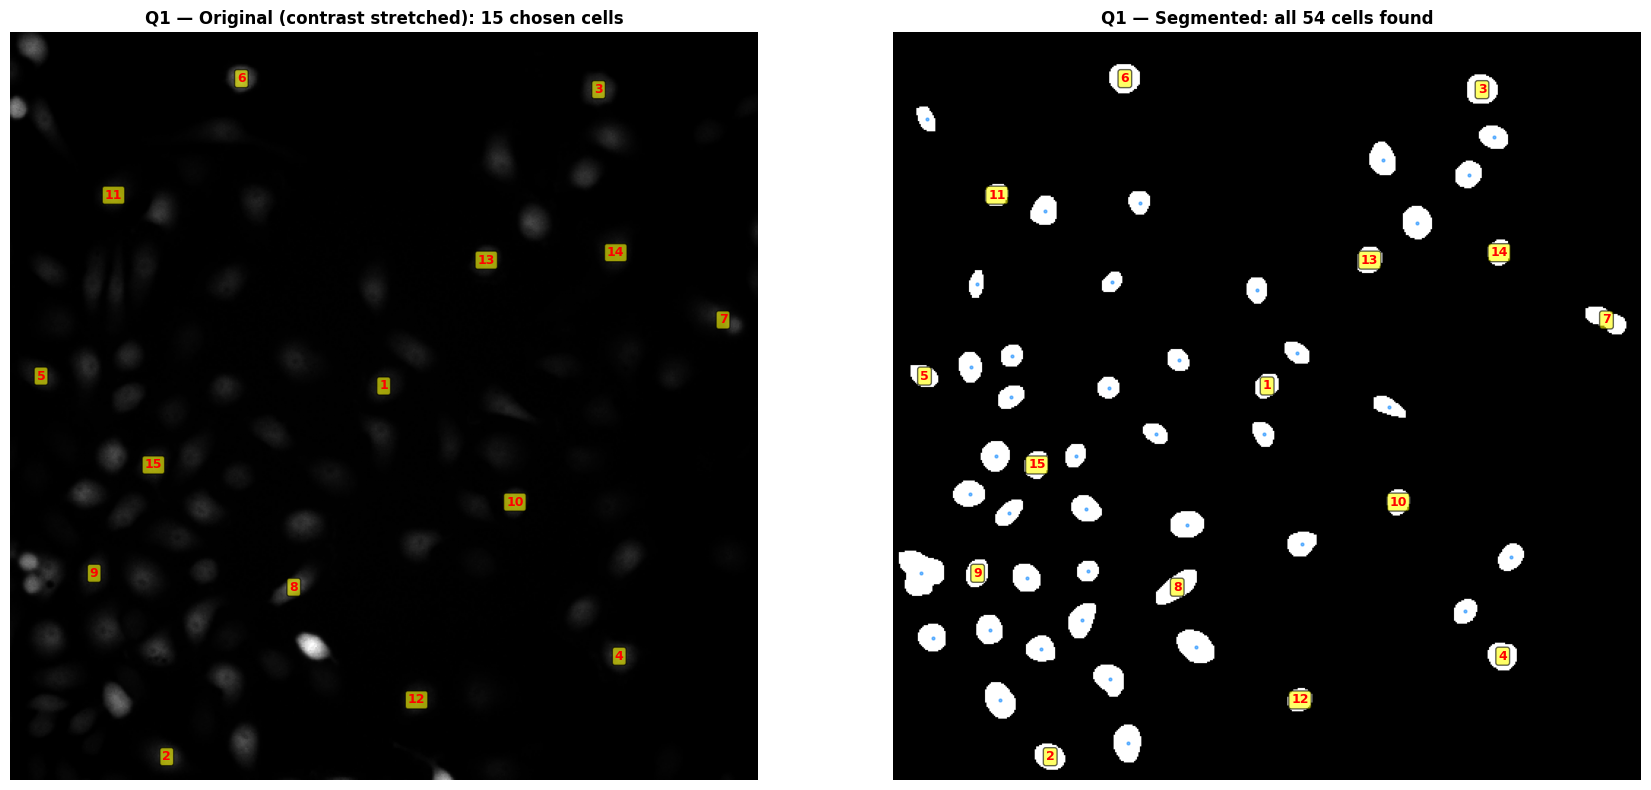

In [47]:
# Get all cells from the already-segmented frame 0
cells_frame0 = get_centroids(labeled0, img0)
print(f'Cells detected in frame 0: {len(cells_frame0)}')

# Print size distribution
sizes = sorted([c['size'] for c in cells_frame0], reverse=True)
print(f'Size range: {min(sizes):.0f} – {max(sizes):.0f}px')
print(f'Median size: {np.median(sizes):.0f}px')

SIZE_MIN = 200
SIZE_MAX = 469

candidates = [c for c in cells_frame0 if SIZE_MIN <= c['size'] <= SIZE_MAX]
print(f'Candidates after size filter: {len(candidates)}')

# Farthest-point sampling for maximum spatial spread
positions = np.array([[c['cx'], c['cy']] for c in candidates])

# Seed: cell closest to image centre (least likely to drift out of frame)
img_cx, img_cy = arr0.shape[1] / 2, arr0.shape[0] / 2
dists_to_centre = np.sqrt((positions[:, 0] - img_cx)**2 + (positions[:, 1] - img_cy)**2)
chosen_idx = [int(np.argmin(dists_to_centre))]

while len(chosen_idx) < 15:
    chosen_pos = positions[chosen_idx]
    remaining_idx = [i for i in range(len(candidates)) if i not in chosen_idx]
    # For each remaining candidate, find its distance to the nearest chosen cell
    min_dists = np.array([
        np.min(np.sqrt(((chosen_pos - positions[i]) ** 2).sum(axis=1)))
        for i in remaining_idx
    ])
    # Pick the one farthest from all chosen cells
    chosen_idx.append(remaining_idx[int(np.argmax(min_dists))])

chosen = [candidates[i] for i in chosen_idx]

chosen_cells = {}
for cell_num, c in enumerate(chosen, start=1):
    chosen_cells[cell_num] = {
        'label_id': c['id'],
        'cx': c['cx'],
        'cy': c['cy'],
        'size': c['size'],
    }
    print(f'Cell {cell_num:2d}: label={c["id"]}, ' f'center=({c["cx"]:.1f}, {c["cy"]:.1f}), ' f'size={c["size"]:.0f}px')

# Visualise: show BOTH original and segmented side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(stretch(arr0), cmap='gray')
axes[0].set_title('Q1 — Original (contrast stretched): 15 chosen cells', fontweight='bold')
axes[0].axis('off')
for cn, info in chosen_cells.items():
    axes[0].text(info['cx'], info['cy'], str(cn), color='red', fontsize=9, fontweight='bold', ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.6))

# Right: segmented binary with ALL detected cells labeled
seg_arr = np.array(labeled0) > 0
axes[1].imshow(seg_arr, cmap='gray')
axes[1].set_title(f'Q1 — Segmented: all {len(cells_frame0)} cells found', fontweight='bold')
axes[1].axis('off')

for c in cells_frame0:
    is_chosen = any(info['label_id'] == c['id'] for info in chosen_cells.values())
    if is_chosen:
        label = str(next(cn for cn, info in chosen_cells.items()
                         if info['label_id'] == c['id']))
        axes[1].text(c['cx'], c['cy'], label, color='red', fontsize=9, fontweight='bold', ha='center', va='center',  bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.6))
    else:
        axes[1].plot(c['cx'], c['cy'], '.', color='dodgerblue', markersize=4, alpha=0.6)

plt.tight_layout()
plt.show()

In [48]:
N_FRAMES = 30
MAX_DIST = 30 ## Maximum displacement- ADJUST THIS...

def track_all_frames(chosen_cells, series_pattern, n_frames=N_FRAMES, max_dist=MAX_DIST):
    """
    Tracks chosen_cells across all frames using nearest-centroid matching.
    CRITERI: For each cell at frame t, find the cell in frame t+1 whos centroid is closest (Euclidean distance) within max_dist pixels.
    MOTIVATION: Cancer cells move slowly over 2 minutes so large jumps are biologically implausible. The radius cap prevents mis-assignment to a different distant cell. If no match found, last known position is held.
    Returns: {cell_num: [(cx, cy), ...]} — one (cx,cy) per frame.
    """
    traces = {cn: [(info['cx'], info['cy'])] for cn, info in chosen_cells.items()}
    current_pos = {cn: (info['cx'], info['cy'])   for cn, info in chosen_cells.items()}

    for f in range(1, n_frames):
        img_f, _, labeled_f, _ = segment_cells(series_pattern.format(f))
        cells_f = get_centroids(labeled_f, img_f)

        for cn in chosen_cells:
            prev_cx, prev_cy = current_pos[cn]
            best_dist = max_dist
            best_pos  = None

            for c in cells_f:
                dist = np.sqrt((c['cx'] - prev_cx)**2 + (c['cy'] - prev_cy)**2)
                if dist < best_dist:
                    best_dist = dist
                    best_pos  = (c['cx'], c['cy'])

            if best_pos is not None:
                current_pos[cn] = best_pos
            traces[cn].append(current_pos[cn])

        if f % 5 == 0 or f == n_frames - 1:
            print(f'  Frame {f:02d}/{n_frames-1} done')

    return traces

print('Tracking Control Series (frames 0-29)...')
ctrl_traces = track_all_frames(chosen_cells, 'MTLn3-ctrl{:04d}.tif')

Tracking Control Series (frames 0-29)...
  Frame 05/29 done
  Frame 10/29 done
  Frame 15/29 done
  Frame 20/29 done
  Frame 25/29 done
  Frame 29/29 done


 ### Question 3 — Manual validation on 5 cells (ground truth check)

 **Validation procedure:**
For 5 cells we overlay the tracked position on 6 evenly-spaced raw frames.

We visually confirm that:
   
   (a) the red dot sits on the correct cell body in each frame
   
   (b) the cyan trace path is spatially smooth and continuous

 A dot landing on the wrong cell or a sudden jump = tracking error for that frame.
 This acts as a ground truth check — we know which cell we started with in frame 0
 and verify the algorithm follows it correctly through the sequence.

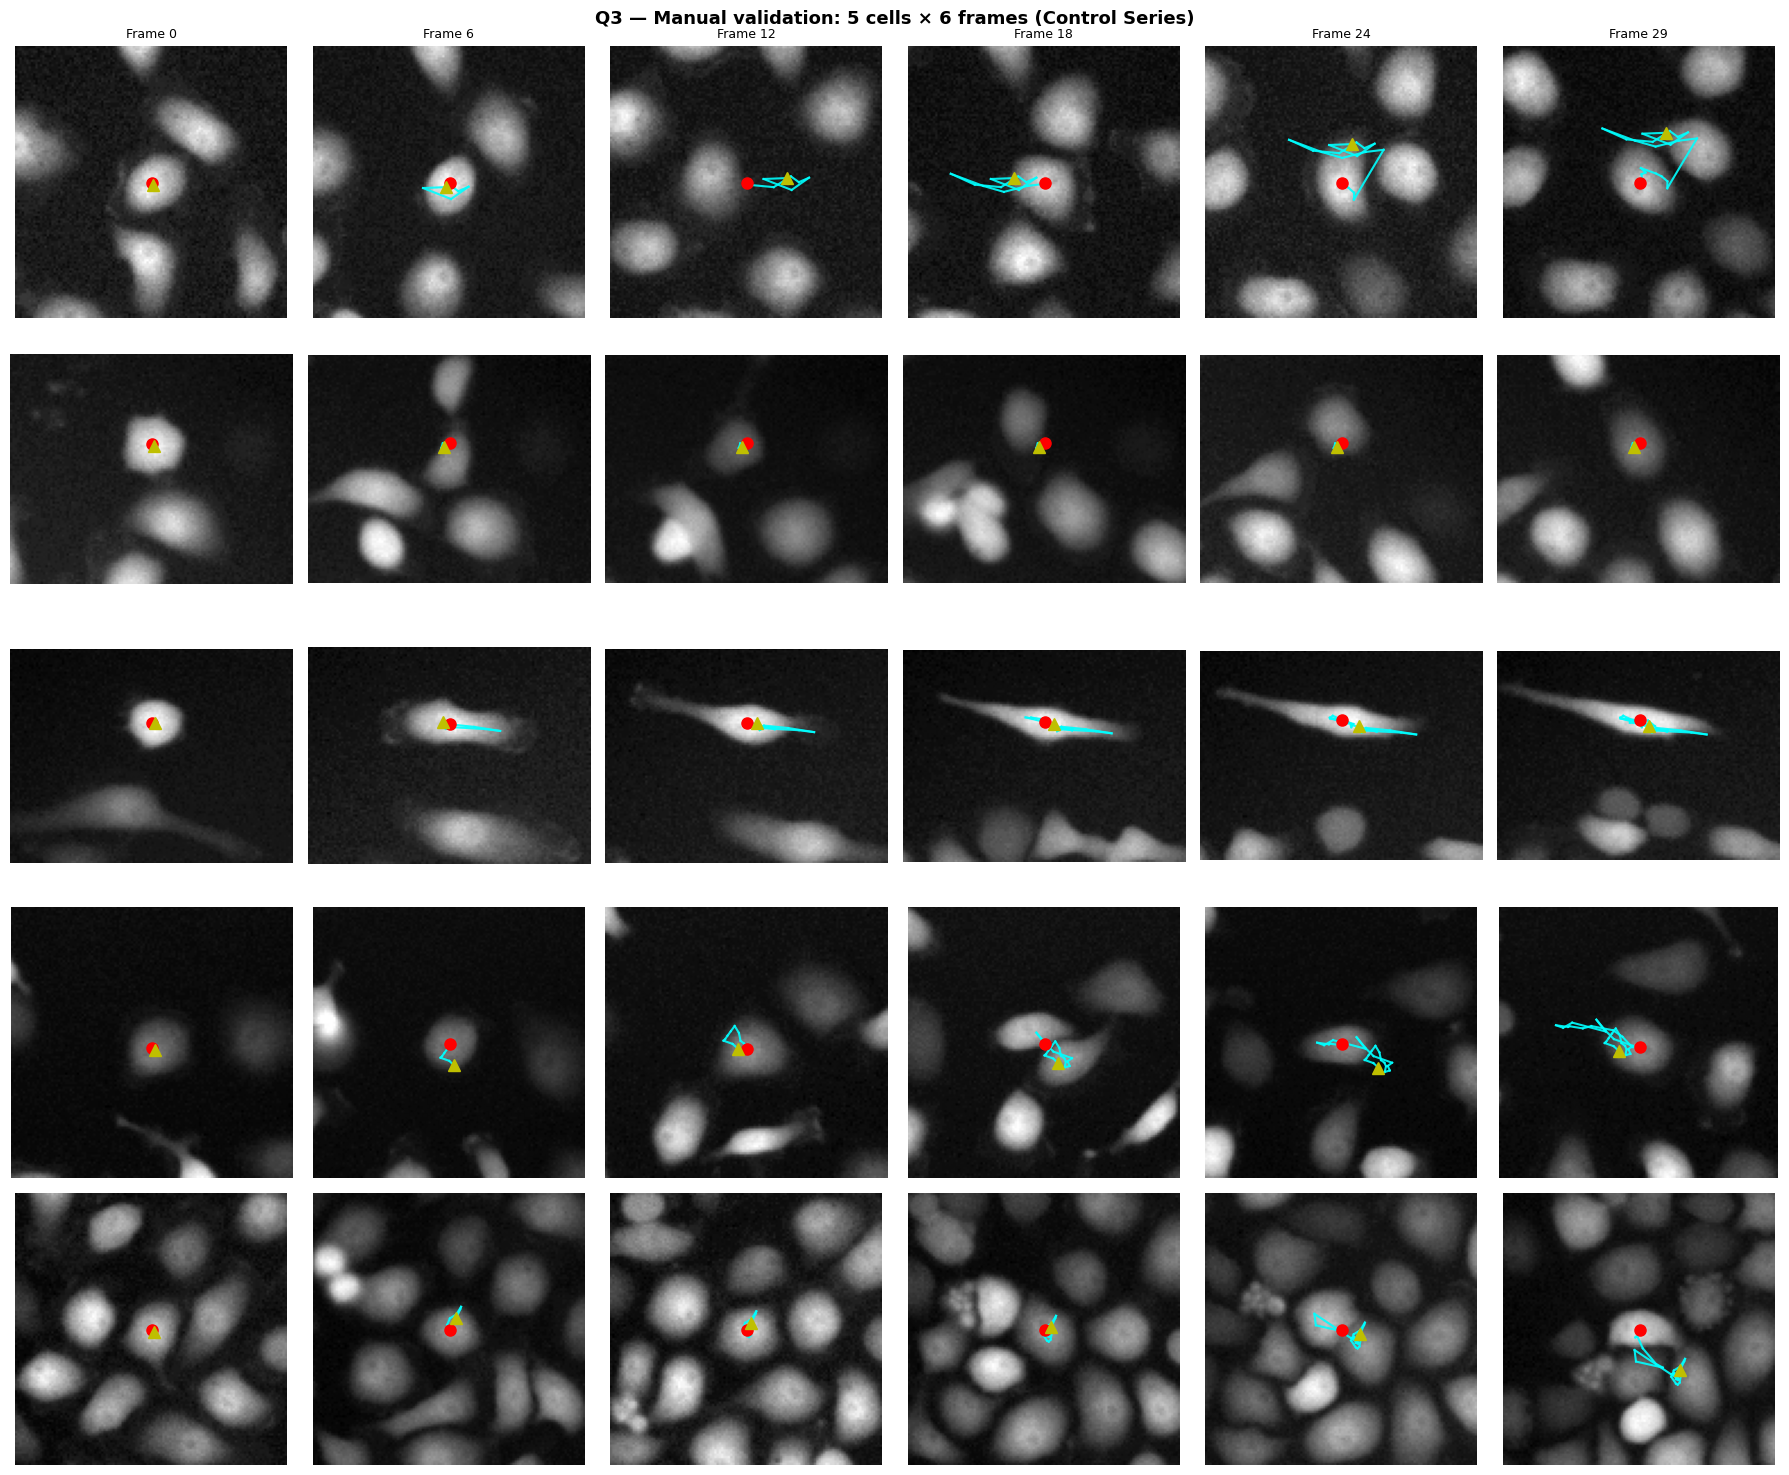

In [49]:
VALIDATE = [1, 3, 6, 12, 15]
CHECK_FRAMES = [0, 6, 12, 18, 24, 29]
ZOOM = 60  # pixels around the cell center to show

fig, axes = plt.subplots(len(VALIDATE), len(CHECK_FRAMES), figsize=(len(CHECK_FRAMES) * 3, len(VALIDATE) * 3))
fig.suptitle('Q3 — Manual validation: 5 cells × 6 frames (Control Series)',
             fontweight='bold', fontsize=13)

for row, cn in enumerate(VALIDATE):
    for col, f in enumerate(CHECK_FRAMES):
        img_f = dip.ImageReadTIFF(f'MTLn3-ctrl{f:04d}.tif')
        arr_f = np.array(img_f)
        h, w = arr_f.shape[:2]

        # Current tracked position
        cx, cy = ctrl_traces[cn][f]
        cx, cy = int(cx), int(cy)

        # Zoom window — clamp to image bounds
        x0 = max(0, cx - ZOOM);  x1 = min(w, cx + ZOOM)
        y0 = max(0, cy - ZOOM);  y1 = min(h, cy + ZOOM)

        # Crop image to zoom window
        crop = arr_f[y0:y1, x0:x1]

        # Contrast stretch crop for visibility (float32 images are very dark)
        cmin, cmax = crop.min(), crop.max()
        if cmax > cmin:
            crop = (crop - cmin) / (cmax - cmin)

        axes[row, col].imshow(crop, cmap='gray', vmin=0, vmax=1)

        # Re-project trace into crop coordinates
        for i in range(1, f + 1):
            px0, py0 = ctrl_traces[cn][i-1]
            px1, py1 = ctrl_traces[cn][i]
            # Only draw if within zoom window
            axes[row, col].plot( [px0 - x0, px1 - x0], [py0 - y0, py1 - y0], '-', color='cyan', linewidth=1.5, alpha=0.9)

        # Current position marker in crop coords
        axes[row, col].plot(cx - x0, cy - y0, 'ro', markersize=8)

        # Start position marker
        sx, sy = ctrl_traces[cn][0]
        if x0 <= sx <= x1 and y0 <= sy <= y1:
            axes[row, col].plot(sx - x0, sy - y0, 'y^', markersize=8)

        if row == 0:
            axes[row, col].set_title(f'Frame {f}', fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel(f'Cell {cn}', fontsize=9, rotation=90, labelpad=4, va='center')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Question 4 — Apply to 15 cells in Control AND Experimental Series

EGF cells found in frame 0: 37
Size range: 155 – 787px
Median size: 229px
Candidates after size filter: 34
EGF Cell  1: label=17, center=(253.5, 258.2), size=263px
EGF Cell  2: label=3, center=(74.2, 46.3), size=309px
EGF Cell  3: label=10, center=(494.2, 123.7), size=237px
EGF Cell  4: label=34, center=(40.3, 408.3), size=196px
EGF Cell  5: label=1, center=(288.2, 12.2), size=178px
EGF Cell  6: label=32, center=(427.4, 369.2), size=197px
EGF Cell  7: label=35, center=(214.6, 410.8), size=187px
EGF Cell  8: label=16, center=(64.2, 254.4), size=259px
EGF Cell  9: label=13, center=(237.9, 135.0), size=376px
EGF Cell 10: label=27, center=(124.0, 330.2), size=239px
EGF Cell 11: label=9, center=(403.7, 103.1), size=197px
EGF Cell 12: label=23, center=(316.1, 318.0), size=215px
EGF Cell 13: label=24, center=(14.2, 320.2), size=218px
EGF Cell 14: label=11, center=(50.5, 124.1), size=155px
EGF Cell 15: label=37, center=(113.5, 429.0), size=176px


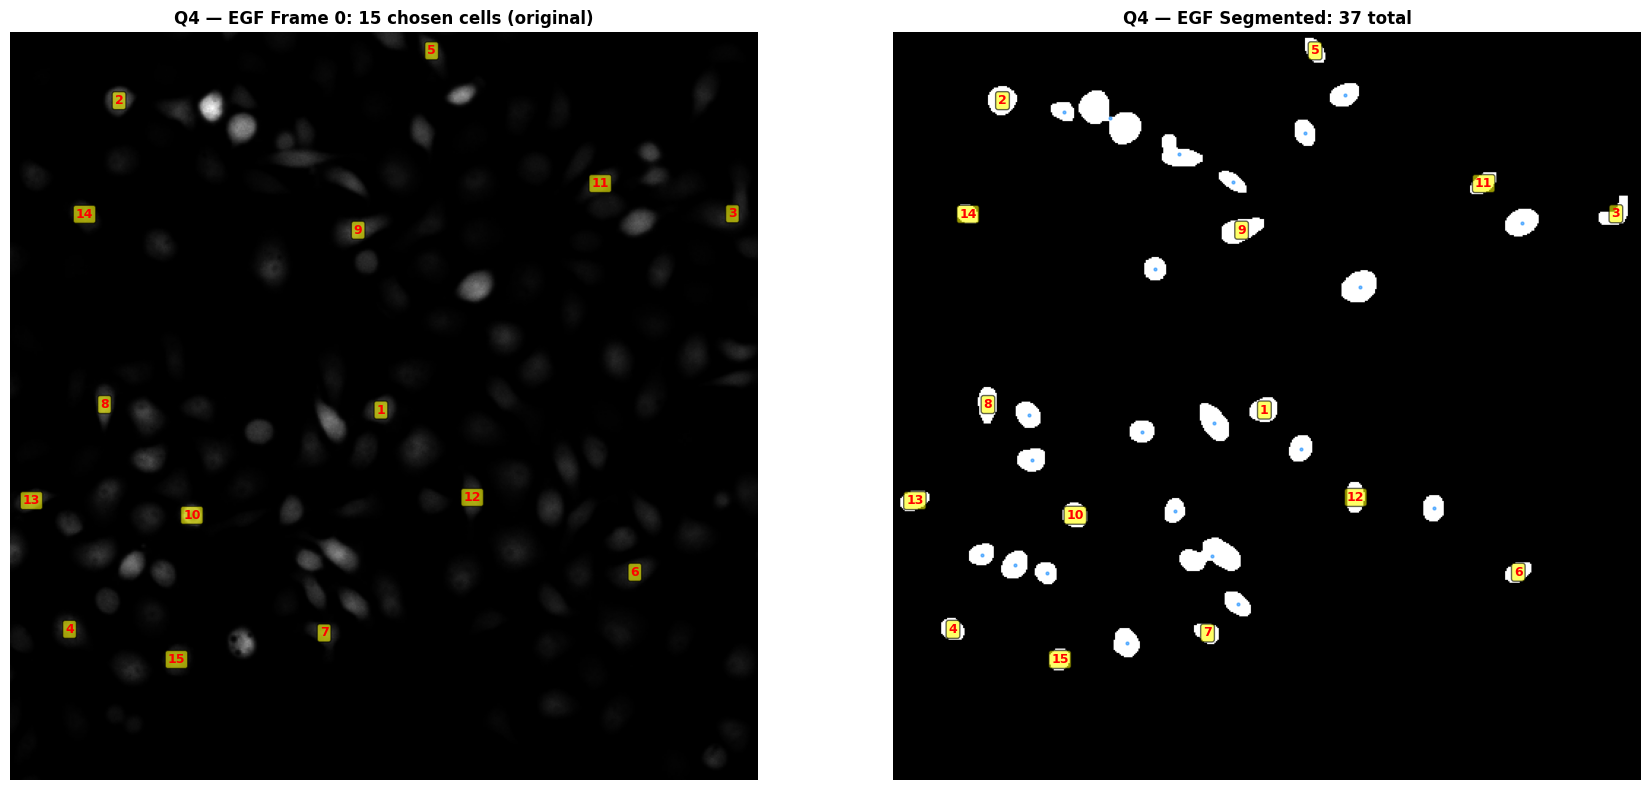

In [50]:
# Pick cells from Experimental frame 0
img0e, _, labeled0e, _ = segment_cells('MTLn3+EGF0000.tif')
arr0e = np.array(img0e)

cells_frame0e = get_centroids(labeled0e, img0e)
print(f'EGF cells found in frame 0: {len(cells_frame0e)}')

# Print size distribution
sizes_e = sorted([c['size'] for c in cells_frame0e], reverse=True)
print(f'Size range: {min(sizes_e):.0f} – {max(sizes_e):.0f}px')
print(f'Median size: {np.median(sizes_e):.0f}px')

SIZE_MIN = 150
SIZE_MAX = 400

candidates_e = [c for c in cells_frame0e if SIZE_MIN <= c['size'] <= SIZE_MAX]
print(f'Candidates after size filter: {len(candidates_e)}')

positions_e = np.array([[c['cx'], c['cy']] for c in candidates_e])

# Seed: cell closest to image centre
img_cx_e, img_cy_e = arr0e.shape[1] / 2, arr0e.shape[0] / 2
dists_to_centre_e = np.sqrt((positions_e[:, 0] - img_cx_e)**2 + (positions_e[:, 1] - img_cy_e)**2)
chosen_idx_e = [int(np.argmin(dists_to_centre_e))]

while len(chosen_idx_e) < min(15, len(candidates_e)):
    chosen_pos_e  = positions_e[chosen_idx_e]
    remaining_e   = [i for i in range(len(candidates_e)) if i not in chosen_idx_e]
    min_dists_e   = np.array([ np.min(np.sqrt(((chosen_pos_e - positions_e[i]) ** 2).sum(axis=1)))
        for i in remaining_e
    ])
    chosen_idx_e.append(remaining_e[int(np.argmax(min_dists_e))])

chosen_e = [candidates_e[i] for i in chosen_idx_e]

chosen_cells_e = {}
for cn, c in enumerate(chosen_e, start=1):
    chosen_cells_e[cn] = {
        'label_id': c['id'],
        'cx': c['cx'],
        'cy': c['cy'],
        'size': c['size'],
    }
    print(f'EGF Cell {cn:2d}: label={c["id"]}, ' f'center=({c["cx"]:.1f}, {c["cy"]:.1f}), 'f'size={c["size"]:.0f}px')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(stretch(arr0e), cmap='gray')
axes[0].set_title('Q4 — EGF Frame 0: 15 chosen cells (original)', fontweight='bold')
axes[0].axis('off')
for cn, info in chosen_cells_e.items():
    axes[0].text(info['cx'], info['cy'], str(cn), color='red', fontsize=9, fontweight='bold', ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.6))

axes[1].imshow(np.array(labeled0e) > 0, cmap='gray')
axes[1].set_title(f'Q4 — EGF Segmented: {len(cells_frame0e)} total', fontweight='bold')
axes[1].axis('off')

for c in cells_frame0e:
    is_chosen = any(info['label_id'] == c['id'] for info in chosen_cells_e.values())
    if is_chosen:
        cn_label = str(next(cn for cn, info in chosen_cells_e.items()
                            if info['label_id'] == c['id']))
        axes[1].text(c['cx'], c['cy'], cn_label, color='red', fontsize=9, fontweight='bold', ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.6))
    else:
        axes[1].plot(c['cx'], c['cy'], '.', color='dodgerblue', markersize=4, alpha=0.6)

plt.tight_layout()
plt.show()


Tracking Experimental (+EGF) Series (frames 0-29)
  Frame 05/29 done
  Frame 10/29 done
  Frame 15/29 done
  Frame 20/29 done
  Frame 25/29 done
  Frame 29/29 done


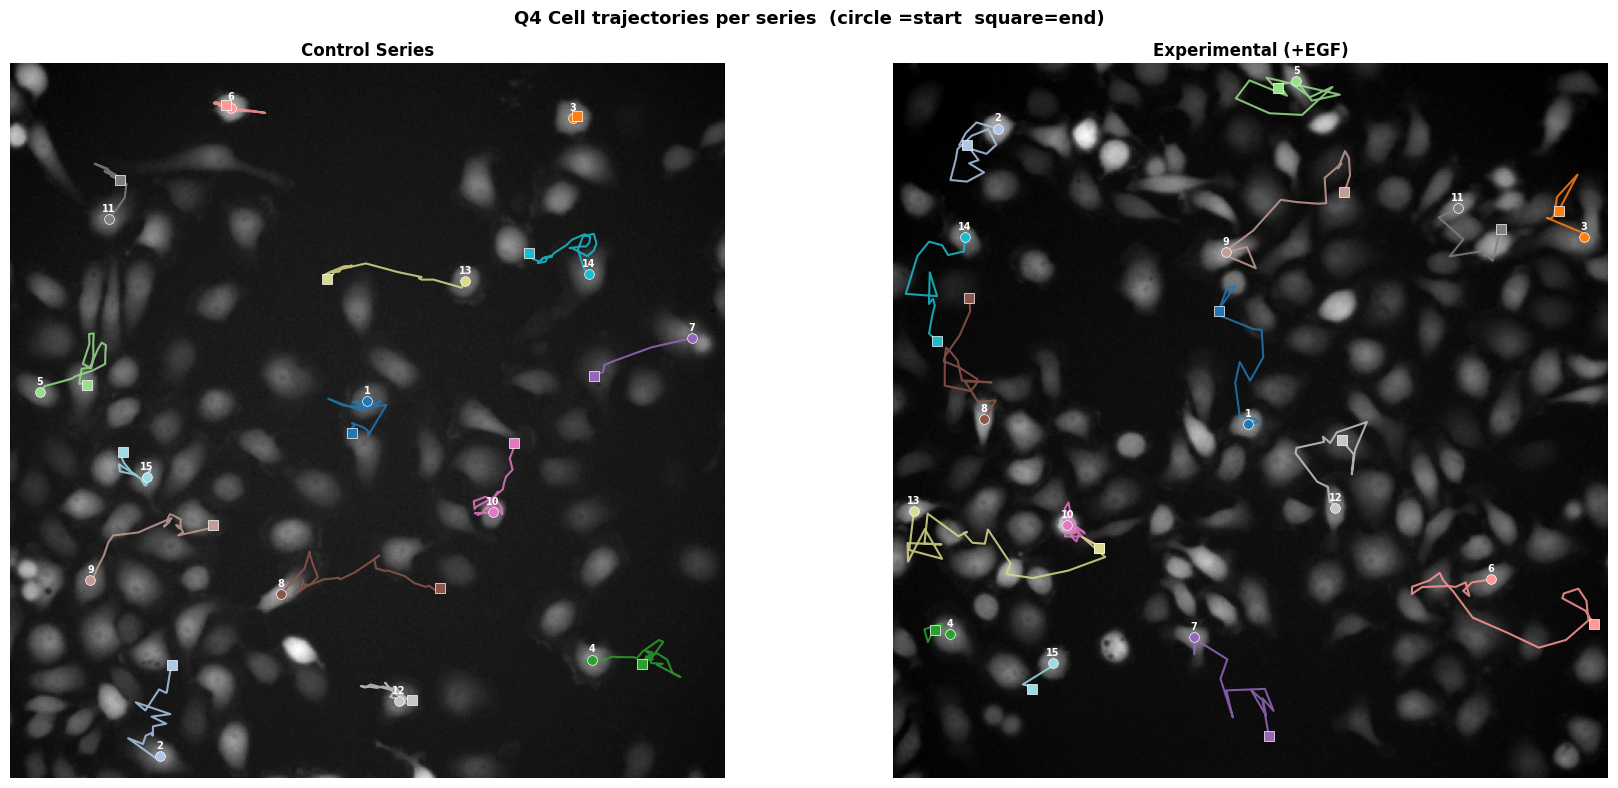

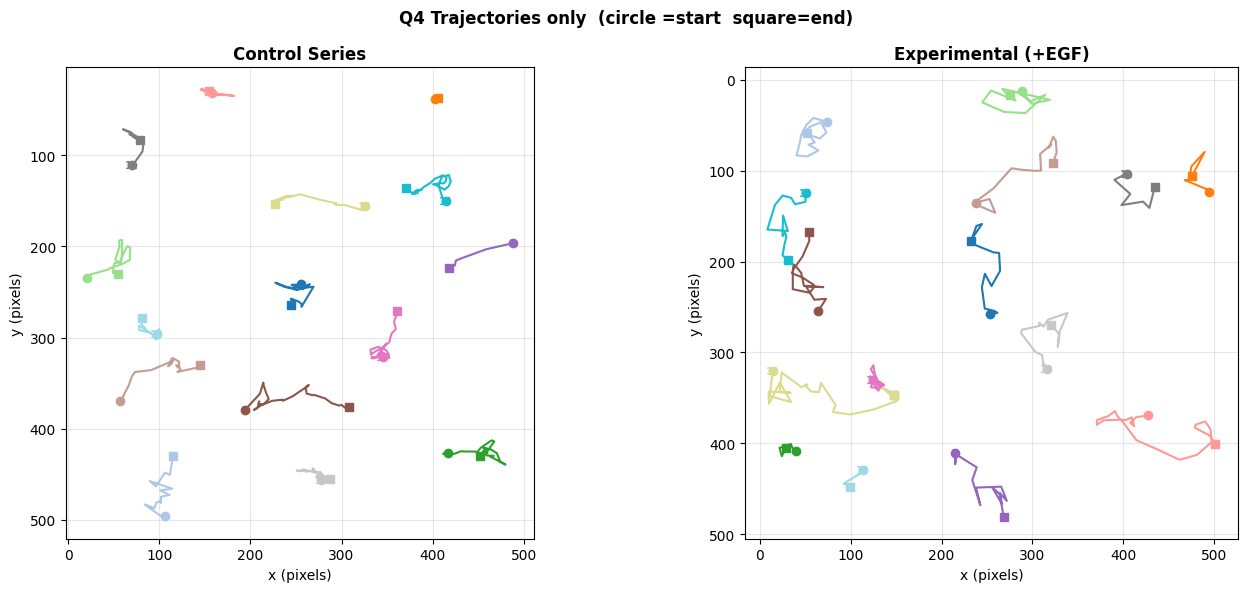

In [51]:
print('Tracking Experimental (+EGF) Series (frames 0-29)')
egf_traces = track_all_frames(chosen_cells_e, 'MTLn3+EGF{:04d}.tif')

# Visualisation 1

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
colors = plt.cm.tab20(np.linspace(0, 1, 15))

for ax, traces, chosen, title, frame0_file in [
    (axes[0], ctrl_traces, chosen_cells,   'Control Series','MTLn3-ctrl0000.tif'),
    (axes[1], egf_traces,  chosen_cells_e, 'Experimental (+EGF)', 'MTLn3+EGF0000.tif'),
]:
    bg = stretch(np.array(dip.ImageReadTIFF(frame0_file)))
    ax.imshow(bg, cmap='gray', vmin=0, vmax=1)

    # Only plot cells that exist in this series
    for cn in chosen.keys():
        color = colors[cn - 1]
        xs = [p[0] for p in traces[cn]]
        ys = [p[1] for p in traces[cn]]
        ax.plot(xs, ys, '-',  color=color, linewidth=1.5, alpha=0.85)
        ax.plot(xs[0],  ys[0],  'o', color=color, markersize=7, markeredgecolor='white', markeredgewidth=0.5)
        ax.plot(xs[-1], ys[-1], 's', color=color, markersize=7, markeredgecolor='white', markeredgewidth=0.5)
        ax.text(xs[0], ys[0] - 8, str(cn), color='white', fontsize=7, fontweight='bold', ha='center', va='center')

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

fig.suptitle('Q4 Cell trajectories per series  (circle =start  square=end)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


# Visualisation 2: Trace-only plot (no background) for clarity

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, traces, chosen, title in [ (axes[0], ctrl_traces, chosen_cells,   'Control Series'), (axes[1], egf_traces,  chosen_cells_e, 'Experimental (+EGF)'), ]:

    for cn in chosen.keys():
        color = colors[cn - 1]
        xs = [p[0] for p in traces[cn]]
        ys = [p[1] for p in traces[cn]]
        ax.plot(xs, ys, '-',  color=color, linewidth=1.5)
        ax.plot(xs[0],  ys[0],  'o', color=color, markersize=6)
        ax.plot(xs[-1], ys[-1], 's', color=color, markersize=6)
        ax.text(xs[0], ys[0], str(cn), fontsize=7, fontweight='bold', ha='center', va='center', color=color)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle('Q4 Trajectories only  (circle =start  square=end)', fontweight='bold')
plt.tight_layout()
plt.show()


# Part 2

In [52]:
def get_stats_for_cell(frames_of_a_cell):
	"""
	Computes the mean, std_dev and smoothness and uniformity of an input cell over all frames of that cell.
	"""
	# uniformity
	histogram_lookup_table = {}
	valid_counter = 0

	area_and_perimeter_per_frame = []
	roundness_per_frame = []

	# valid counter == area
	for cell in frames_of_a_cell:
		cell_alter = dip.Image(cell)
		mask = cell_alter > 0
		area_and_perimeter_per_frame.append(dip.MeasurementTool.Measure(dip.Label(mask), features=["Size", "Perimeter"]))
		roundness_per_frame.append(dip.MeasurementTool.Measure(dip.Label(mask), features=["Roundness"]))
		for row in cell:
			for pixel_value in row:
				if pixel_value != 0:
					histogram_lookup_table[pixel_value] = histogram_lookup_table.get(pixel_value, 0) + 1
					valid_counter += 1
	average_roundness_per_frame = sum(i["Roundness"][1][0] for i in roundness_per_frame) / len(roundness_per_frame)
	average_perimeter_per_frame = sum(i["Perimeter"][1][0] for i in area_and_perimeter_per_frame) / len(area_and_perimeter_per_frame)

	histogram_lookup_table_normalized = {}
	for pixel_value in histogram_lookup_table.keys():
		histogram_lookup_table_normalized[pixel_value] = histogram_lookup_table[pixel_value] / valid_counter
	uniformity = sum([i ** 2 for i in histogram_lookup_table_normalized.values()])

	# mean
	mean = sum([k * histogram_lookup_table[k] for k in histogram_lookup_table.keys()]) / valid_counter
	# standard deviation
	summie = 0 
	for cell in frames_of_a_cell:
		for row in cell:
			for pixel_value in row:
				summie += (pixel_value - mean)**2
	std_dev = float(np.sqrt(summie / valid_counter))
	# smoothness
	smoothness = 1 - (1/(1 + (std_dev ** 2)))
	return mean, std_dev, smoothness, uniformity, valid_counter/len(frames_of_a_cell), average_roundness_per_frame, average_perimeter_per_frame

def compute_distance(trace):
	"""
	Computes a distance measure in two ways:
	First: begin to end. (distance between start and end-point)
	Second: Total trajectory: total distance travelled.
	"""
	xs = [p[0] for p in trace]
	ys = [p[1] for p in trace]

	first_distance = float(np.sqrt((xs[-1] - xs[0]) ** 2 + (ys[-1] - ys[0]) ** 2))

	second_distance = 0
	for i, x in enumerate(xs):
		if i != 0:
			second_distance += float(np.sqrt((xs[i] - xs[i-1]) ** 2 + (ys[i] - ys[i-1]) ** 2))
	return first_distance, second_distance

In [53]:
def track_all_frames_with_mask_output(chosen_cells, series_pattern, n_frames=N_FRAMES, max_dist=MAX_DIST):
    """
    Tracks chosen_cells across all frames using nearest-centroid matching.
    CRITERI: For each cell at frame t, find the cell in frame t+1 whos centroid is closest (Euclidean distance) within max_dist pixels.
    MOTIVATION: Cancer cells move slowly over 2 minutes so large jumps are biologically implausible. The radius cap prevents mis-assignment to a different distant cell. If no match found, last known position is held.
    Returns: {cell_num: [(cx, cy), ...]} — one (cx,cy) per frame.
    """
    traces = {cn: [(info['cx'], info['cy'])] for cn, info in chosen_cells.items()}
    current_pos = {cn: (info['cx'], info['cy'])   for cn, info in chosen_cells.items()}
    cell_matches = {cn : [] for cn, info in chosen_cells.items()}

    for f in range(1, n_frames):
        img_f, _, labeled_f, _ = segment_cells(series_pattern.format(f))
        cells_f = get_centroids(labeled_f, img_f)

        for cn in chosen_cells:
            prev_cx, prev_cy = current_pos[cn]
            best_dist = max_dist
            best_pos  = None

            for c in cells_f:
                dist = np.sqrt((c['cx'] - prev_cx)**2 + (c['cy'] - prev_cy)**2)
                if dist < best_dist:
                    best_dist = dist
                    best_pos  = (c['cx'], c['cy'])
                    best_single_cell_mask_match = c['single_cell']

            if best_pos is not None:
                current_pos[cn] = best_pos
            traces[cn].append(current_pos[cn])
            cell_matches[cn].append(best_single_cell_mask_match)

        if f % 5 == 0 or f == n_frames - 1:
            print(f'  Frame {f:02d}/{n_frames-1} done')

    return traces, cell_matches

print('Tracking Control Series (frames 0-29)...')
ctrl_traces, ctrl_traces_single_cell = track_all_frames_with_mask_output(chosen_cells, 'MTLn3-ctrl{:04d}.tif')
print('Tracking Experiment Series (frames 0-29)...')
egf_traces, egf_traces_single_cell = track_all_frames_with_mask_output(chosen_cells_e, 'MTLn3+EGF{:04d}.tif')

Tracking Control Series (frames 0-29)...
  Frame 05/29 done
  Frame 10/29 done
  Frame 15/29 done
  Frame 20/29 done
  Frame 25/29 done
  Frame 29/29 done
Tracking Experiment Series (frames 0-29)...
  Frame 05/29 done
  Frame 10/29 done
  Frame 15/29 done
  Frame 20/29 done
  Frame 25/29 done
  Frame 29/29 done


In [54]:
all_cell_stats = {"control": {}, "experiment": {}}

In [55]:
for mask, chosen in [(ctrl_traces_single_cell, chosen_cells)]:
	for cn in chosen.keys():
		all_cell_stats["control"][cn] = {}
		stats_for_cell = get_stats_for_cell(mask[cn])
		print(f'Cell {cn:2d}: label={chosen[cn]["label_id"]}, '
	  		f'mean intensity = {stats_for_cell[0]} '
	  		f'std dev = {stats_for_cell[1]} '
	  		f'Smoothness  = {stats_for_cell[2]} '
	  		f'Uniformity = {stats_for_cell[3]} '
			f'Area = {stats_for_cell[4]} '
			f'Perimeter = {stats_for_cell[6]} '
			f'Roundness = {stats_for_cell[5]} '
		)
		all_cell_stats["control"][cn]["mean_intensity"] = stats_for_cell[0]
		all_cell_stats["control"][cn]["std_dev"] = stats_for_cell[1]
		all_cell_stats["control"][cn]["smoothness"] = stats_for_cell[2]
		all_cell_stats["control"][cn]["uniformity"] = stats_for_cell[3]
		all_cell_stats["control"][cn]["area"] = stats_for_cell[4]
		all_cell_stats["control"][cn]["perimeter"] = stats_for_cell[6]
		all_cell_stats["control"][cn]["roundness"] = stats_for_cell[5]


for mask, chosen in [(egf_traces_single_cell, chosen_cells_e)]:
	for cn in chosen.keys():
		stats_for_cell = get_stats_for_cell(mask[cn])
		print(f'Cell {cn:2d}: label={chosen[cn]["label_id"]}, '
	  		f'mean intensity = {stats_for_cell[0]} '
	  		f'std dev = {stats_for_cell[1]} '
	  		f'Smoothness  = {stats_for_cell[2]} '
	  		f'Uniformity = {stats_for_cell[3]} '
			f'Area = {stats_for_cell[4]} '
			f'Perimeter = {stats_for_cell[6]} '
			f'Roundness = {stats_for_cell[5]} '
	  	)
		all_cell_stats["experiment"][cn] = {}
		all_cell_stats["experiment"][cn]["mean_intensity"] = stats_for_cell[0]
		all_cell_stats["experiment"][cn]["std_dev"] = stats_for_cell[1]
		all_cell_stats["experiment"][cn]["smoothness"] = stats_for_cell[2]
		all_cell_stats["experiment"][cn]["uniformity"] = stats_for_cell[3]
		all_cell_stats["experiment"][cn]["area"] = stats_for_cell[4]
		all_cell_stats["experiment"][cn]["perimeter"] = stats_for_cell[6]
		all_cell_stats["experiment"][cn]["roundness"] = stats_for_cell[5]

 

Cell  1: label=22, mean intensity = 16324472.0 std dev = 585678848.0 Smoothness  = 1.0 Uniformity = 0.05505879367704188 Area = 213.06896551724137 Perimeter = 52.31921334324496 Roundness = 0.9716537969187339 
Cell  2: label=54, mean intensity = 30762740.0 std dev = 927365440.0 Smoothness  = 1.0 Uniformity = 0.021567583904245943 Area = 294.8965517241379 Perimeter = 62.65469610186565 Roundness = 0.9331391388465944 
Cell  3: label=2, mean intensity = 31381706.0 std dev = 928274816.0 Smoothness  = 1.0 Uniformity = 0.02055534551564797 Area = 297.41379310344826 Perimeter = 63.004902998417386 Roundness = 0.9311157828432486 
Cell  4: label=49, mean intensity = 21458836.0 std dev = 626671488.0 Smoothness  = 1.0 Uniformity = 0.037638944331351024 Area = 321.51724137931035 Perimeter = 64.62024782600358 Roundness = 0.9649379177501598 
Cell  5: label=21, mean intensity = 19609050.0 std dev = 587714368.0 Smoothness  = 1.0 Uniformity = 0.042289695742066216 Area = 280.51724137931035 Perimeter = 60.45959

# 4.2.2

In [56]:
seconds_between_measurements = 120

for traces, chosen in [(ctrl_traces, chosen_cells)]:
	print("cn, distance_begin_end, velocity_begin_end, complete_trajectory_distance, velocity_complete_trajectory")
	for cn in chosen.keys():
		distance_begin_end, complete_trajectory_distance = compute_distance(traces[cn])
		total_time = len(traces[cn]) * seconds_between_measurements
		velocity_begin_end = distance_begin_end / total_time
		velocity_complete_trajectory = complete_trajectory_distance / total_time
		print(f"{cn}, {distance_begin_end}, {velocity_begin_end}, {complete_trajectory_distance}, {velocity_complete_trajectory}")
		all_cell_stats["control"][cn]["distance_begin_end"] = distance_begin_end
		all_cell_stats["control"][cn]["velocity_begin_end"] = velocity_begin_end
		all_cell_stats["control"][cn]["complete_trajectory_distance"] = complete_trajectory_distance
		all_cell_stats["control"][cn]["velocity_complete_trajectory"] = velocity_complete_trajectory

for traces, chosen in [(egf_traces,  chosen_cells_e)]:
	print("cn, distance_begin_end, velocity_begin_end, complete_trajectory_distance, velocity_complete_trajectory")
	for cn in chosen.keys():
		distance_begin_end, complete_trajectory_distance = compute_distance(traces[cn])
		total_time = len(traces[cn]) * seconds_between_measurements
		velocity_begin_end = distance_begin_end / total_time
		velocity_complete_trajectory = complete_trajectory_distance / total_time
		print(f"{cn}, {distance_begin_end}, {velocity_begin_end}, {complete_trajectory_distance}, {velocity_complete_trajectory}")
		all_cell_stats["experiment"][cn]["distance_begin_end"] = distance_begin_end
		all_cell_stats["experiment"][cn]["velocity_begin_end"] = velocity_begin_end
		all_cell_stats["experiment"][cn]["complete_trajectory_distance"] = complete_trajectory_distance
		all_cell_stats["experiment"][cn]["velocity_complete_trajectory"] = velocity_complete_trajectory




cn, distance_begin_end, velocity_begin_end, complete_trajectory_distance, velocity_complete_trajectory
1, 25.237442407188272, 0.007010400668663409, 170.3323273025797, 0.0473145353618277
2, 65.86506185719257, 0.018295850515886825, 178.0554710915456, 0.04945985308098489
3, 3.26955199680407, 0.0009082088880011305, 6.995771262215705, 0.001943269795059918
4, 35.586049880368876, 0.009885013855658022, 190.92379809120504, 0.05303438835866807
5, 34.105172113774934, 0.009473658920493037, 180.61992795824114, 0.05017220221062254
6, 4.184822015009252, 0.0011624505597247923, 126.51283054030662, 0.03514245292786295
7, 74.95452825085344, 0.020820702291903734, 77.74637882079635, 0.0215962163391101
8, 114.00870684622278, 0.031669085235061886, 216.21206478145362, 0.06005890688373711
9, 96.5077604635854, 0.026807711239884832, 168.3899791703221, 0.04677499421397836
10, 52.27891123268719, 0.014521919786857554, 165.78948915033925, 0.046052635875094235
11, 29.171603369422083, 0.008103223158172801, 143.6920153

In [57]:
all_correlations = {"control": {}, "experiment": {}, "global": {}}

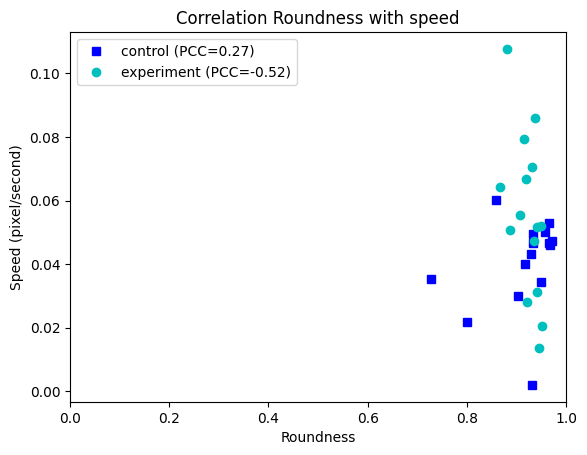

In [58]:
# promising comparisons: Roundness versus speed, uniformity versus speed.


x_keys_control = all_cell_stats["control"].keys()
x_keys_experiment = all_cell_stats["experiment"].keys()

var_a = "roundness"

x_control = [all_cell_stats["control"][i][var_a] for i in x_keys_control]
y_control = [all_cell_stats["control"][i]["velocity_complete_trajectory"] for i in x_keys_control]

x_experiment = [all_cell_stats["experiment"][i][var_a] for i in x_keys_experiment]
y_experiment = [all_cell_stats["experiment"][i]["velocity_complete_trajectory"] for i in x_keys_experiment]

handles = ["bs", "oc"]
labels = ["Control", "Experiment"]

correlation_control = np.corrcoef(x_control, y_control)
correlation_experiment = np.corrcoef(x_experiment, y_experiment)

all_correlations['control'][var_a] = np.corrcoef(x_control, y_control)[0][1]
all_correlations['experiment'][var_a] = np.corrcoef(x_experiment, y_experiment)[0][1]



plt.plot(x_control, y_control, "bs", label=f"control (PCC={correlation_control[0][1]:.2f})")
plt.plot(x_experiment, y_experiment, "oc", label=f"experiment (PCC={correlation_experiment[0][1]:.2f})")
plt.legend()


x_control.extend(x_experiment)
y_control.extend(y_experiment)
all_correlations['global'][var_a] = np.corrcoef(x_control, y_control)[0][1]

ax = plt.gca()
ax.set_xlim([0, 1])
ax.set_xlabel(f"{var_a.capitalize()}")
ax.set_ylabel("Speed (pixel/second)")
ax.set_title("Correlation Roundness with speed")

plt.show()




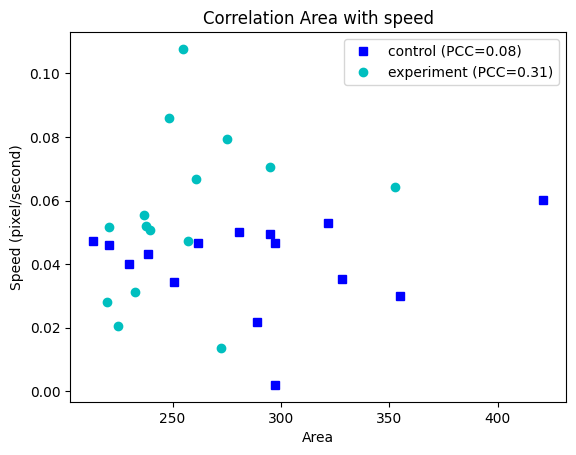

In [59]:
# promising comparisons: Roundness versus speed, uniformity versus speed.


x_keys_control = all_cell_stats["control"].keys()
x_keys_experiment = all_cell_stats["experiment"].keys()

var_a = "area"

x_control = [all_cell_stats["control"][i][var_a] for i in x_keys_control]
y_control = [all_cell_stats["control"][i]["velocity_complete_trajectory"] for i in x_keys_control]

x_experiment = [all_cell_stats["experiment"][i][var_a] for i in x_keys_experiment]
y_experiment = [all_cell_stats["experiment"][i]["velocity_complete_trajectory"] for i in x_keys_experiment]

handles = ["bs", "oc"]
labels = ["Control", "Experiment"]

correlation_control = np.corrcoef(x_control, y_control)
correlation_experiment = np.corrcoef(x_experiment, y_experiment)


all_correlations['control'][var_a] = np.corrcoef(x_control, y_control)[0][1]
all_correlations['experiment'][var_a] = np.corrcoef(x_experiment, y_experiment)[0][1]


plt.plot(x_control, y_control, "bs", label=f"control (PCC={correlation_control[0][1]:.2f})")
plt.plot(x_experiment, y_experiment, "oc", label=f"experiment (PCC={correlation_experiment[0][1]:.2f})")
plt.legend()


x_control.extend(x_experiment)
y_control.extend(y_experiment)
all_correlations['global'][var_a] = np.corrcoef(x_control, y_control)[0][1]

ax = plt.gca()
ax.set_xlabel(var_a.capitalize())
ax.set_ylabel("Speed (pixel/second)")
ax.set_title("Correlation Area with speed")

plt.show()

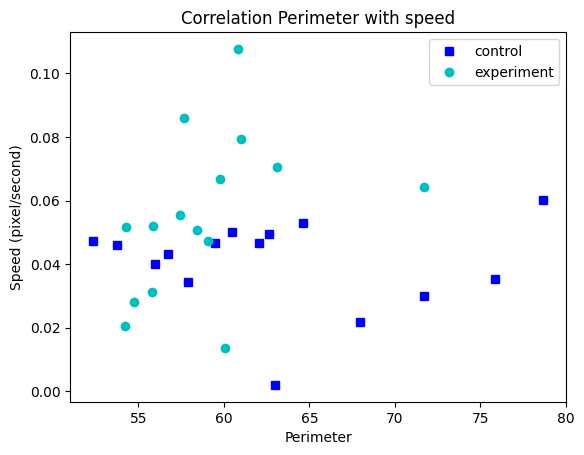

In [60]:
# promising comparisons: Roundness versus speed, uniformity versus speed.


x_keys_control = all_cell_stats["control"].keys()
x_keys_experiment = all_cell_stats["experiment"].keys()

var_a = "perimeter"

x_control = [all_cell_stats["control"][i][var_a] for i in x_keys_control]
y_control = [all_cell_stats["control"][i]["velocity_complete_trajectory"] for i in x_keys_control]

x_experiment = [all_cell_stats["experiment"][i][var_a] for i in x_keys_experiment]
y_experiment = [all_cell_stats["experiment"][i]["velocity_complete_trajectory"] for i in x_keys_experiment]

handles = ["bs", "oc"]
labels = ["Control", "Experiment"]


all_correlations['control'][var_a] = np.corrcoef(x_control, y_control)[0][1]
all_correlations['experiment'][var_a] = np.corrcoef(x_experiment, y_experiment)[0][1]

plt.plot(x_control, y_control, "bs", label="control")
plt.plot(x_experiment, y_experiment, "oc", label="experiment")
plt.legend()


x_control.extend(x_experiment)
y_control.extend(y_experiment)
all_correlations['global'][var_a] = np.corrcoef(x_control, y_control)[0][1]

ax = plt.gca()
ax.set_xlabel(var_a.capitalize())
ax.set_ylabel("Speed (pixel/second)")
ax.set_title("Correlation Perimeter with speed")

plt.show()

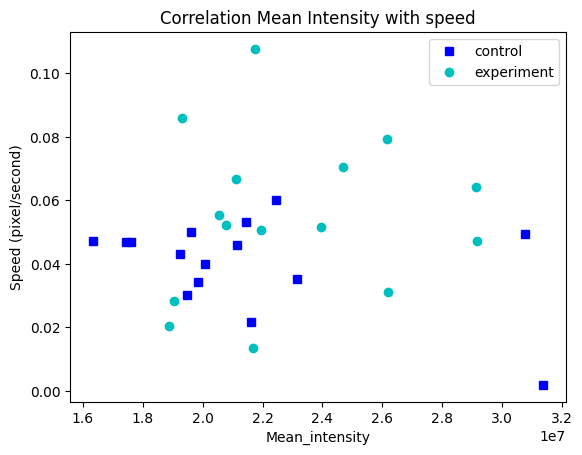

In [61]:
# promising comparisons: Roundness versus speed, uniformity versus speed.


x_keys_control = all_cell_stats["control"].keys()
x_keys_experiment = all_cell_stats["experiment"].keys()

var_a = "mean_intensity"

x_control = [all_cell_stats["control"][i][var_a] for i in x_keys_control]
y_control = [all_cell_stats["control"][i]["velocity_complete_trajectory"] for i in x_keys_control]

x_experiment = [all_cell_stats["experiment"][i][var_a] for i in x_keys_experiment]
y_experiment = [all_cell_stats["experiment"][i]["velocity_complete_trajectory"] for i in x_keys_experiment]

handles = ["bs", "oc"]
labels = ["Control", "Experiment"]


all_correlations['control'][var_a] = np.corrcoef(x_control, y_control)[0][1]
all_correlations['experiment'][var_a] = np.corrcoef(x_experiment, y_experiment)[0][1]

plt.plot(x_control, y_control, "bs", label="control")
plt.plot(x_experiment, y_experiment, "oc", label="experiment")
plt.legend()

x_control.extend(x_experiment)
y_control.extend(y_experiment)
all_correlations['global'][var_a] = np.corrcoef(x_control, y_control)[0][1]


ax = plt.gca()
ax.set_xlabel(var_a.capitalize())
ax.set_ylabel("Speed (pixel/second)")
ax.set_title("Correlation Mean Intensity with speed")

plt.show()

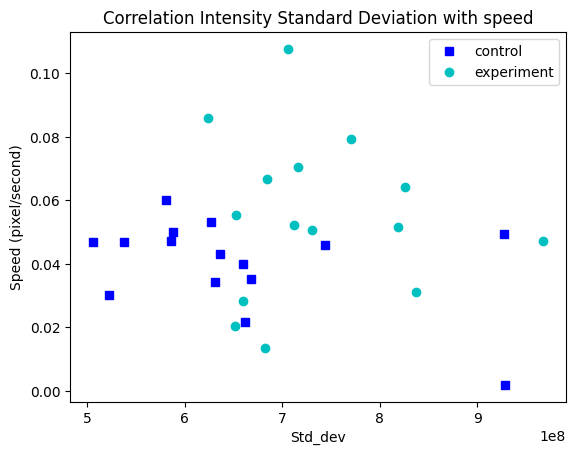

In [62]:
# promising comparisons: Roundness versus speed, uniformity versus speed.


x_keys_control = all_cell_stats["control"].keys()
x_keys_experiment = all_cell_stats["experiment"].keys()

var_a = "std_dev"

x_control = [all_cell_stats["control"][i][var_a] for i in x_keys_control]
y_control = [all_cell_stats["control"][i]["velocity_complete_trajectory"] for i in x_keys_control]

x_experiment = [all_cell_stats["experiment"][i][var_a] for i in x_keys_experiment]
y_experiment = [all_cell_stats["experiment"][i]["velocity_complete_trajectory"] for i in x_keys_experiment]

handles = ["bs", "oc"]
labels = ["Control", "Experiment"]


all_correlations['control'][var_a] = np.corrcoef(x_control, y_control)[0][1]
all_correlations['experiment'][var_a] = np.corrcoef(x_experiment, y_experiment)[0][1]


plt.plot(x_control, y_control, "bs", label="control")
plt.plot(x_experiment, y_experiment, "oc", label="experiment")
plt.legend()


x_control.extend(x_experiment)
y_control.extend(y_experiment)
all_correlations['global'][var_a] = np.corrcoef(x_control, y_control)[0][1]

ax = plt.gca()
ax.set_xlabel(var_a.capitalize())
ax.set_ylabel("Speed (pixel/second)")
ax.set_title("Correlation Intensity Standard Deviation with speed")

plt.show()

/home/nessinmorse/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/nessinmorse/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


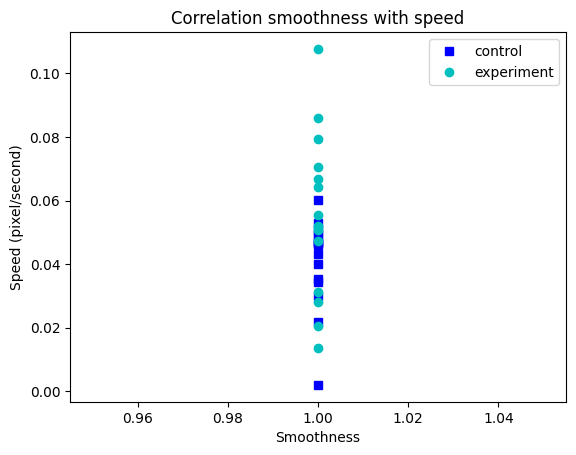

In [63]:
# promising comparisons: Roundness versus speed, uniformity versus speed.


x_keys_control = all_cell_stats["control"].keys()
x_keys_experiment = all_cell_stats["experiment"].keys()

var_a = "smoothness"

x_control = [all_cell_stats["control"][i][var_a] for i in x_keys_control]
y_control = [all_cell_stats["control"][i]["velocity_complete_trajectory"] for i in x_keys_control]

x_experiment = [all_cell_stats["experiment"][i][var_a] for i in x_keys_experiment]
y_experiment = [all_cell_stats["experiment"][i]["velocity_complete_trajectory"] for i in x_keys_experiment]

handles = ["bs", "oc"]
labels = ["Control", "Experiment"]


all_correlations['control'][var_a] = np.corrcoef(x_control, y_control)[0][1]
all_correlations['experiment'][var_a] = np.corrcoef(x_experiment, y_experiment)[0][1]


plt.plot(x_control, y_control, "bs", label="control")
plt.plot(x_experiment, y_experiment, "oc", label="experiment")
plt.legend()


x_control.extend(x_experiment)
y_control.extend(y_experiment)
all_correlations['global'][var_a] = np.corrcoef(x_control, y_control)[0][1]

ax = plt.gca()
ax.set_xlabel(var_a.capitalize())
ax.set_ylabel("Speed (pixel/second)")
ax.set_title("Correlation smoothness with speed")

plt.show()

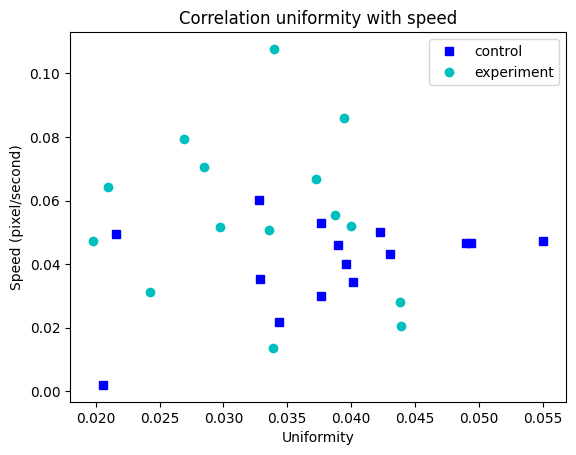

In [64]:
# promising comparisons: Roundness versus speed, uniformity versus speed.


x_keys_control = all_cell_stats["control"].keys()
x_keys_experiment = all_cell_stats["experiment"].keys()

var_a = "uniformity"

x_control = [all_cell_stats["control"][i][var_a] for i in x_keys_control]
y_control = [all_cell_stats["control"][i]["velocity_complete_trajectory"] for i in x_keys_control]

x_experiment = [all_cell_stats["experiment"][i][var_a] for i in x_keys_experiment]
y_experiment = [all_cell_stats["experiment"][i]["velocity_complete_trajectory"] for i in x_keys_experiment]

handles = ["bs", "oc"]
labels = ["Control", "Experiment"]


all_correlations['control'][var_a] = np.corrcoef(x_control, y_control)[0][1]
all_correlations['experiment'][var_a] = np.corrcoef(x_experiment, y_experiment)[0][1]


plt.plot(x_control, y_control, "bs", label="control")
plt.plot(x_experiment, y_experiment, "oc", label="experiment")
plt.legend()

x_control.extend(x_experiment)
y_control.extend(y_experiment)
all_correlations['global'][var_a] = np.corrcoef(x_control, y_control)[0][1]

ax = plt.gca()
ax.set_xlabel(var_a.capitalize())
ax.set_ylabel("Speed (pixel/second)")
ax.set_title("Correlation uniformity with speed")

plt.show()

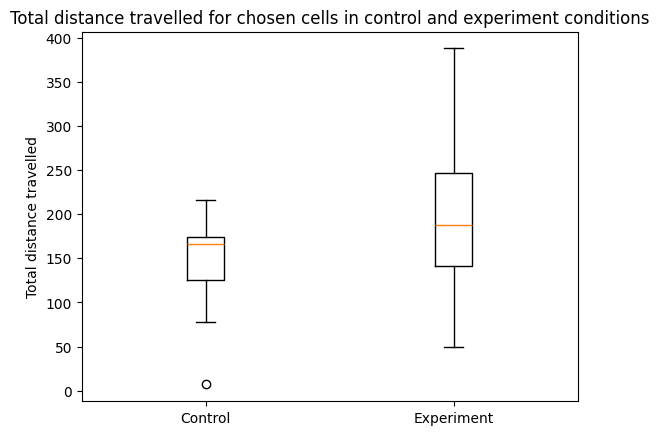

In [65]:
# total travel comparison

x_keys_control = all_cell_stats["control"].keys()
x_keys_experiment = all_cell_stats["experiment"].keys()

y_control = [all_cell_stats["control"][i]["complete_trajectory_distance"] for i in x_keys_control]
y_experiment = [all_cell_stats["experiment"][i]["complete_trajectory_distance"] for i in x_keys_experiment]

data = [y_control, y_experiment]

plt.boxplot(data)
ax = plt.gca()
ax.set_xticklabels(["Control", "Experiment"])
ax.set_ylabel("Total distance travelled")
ax.set_title("Total distance travelled for chosen cells in control and experiment conditions")

plt.show()

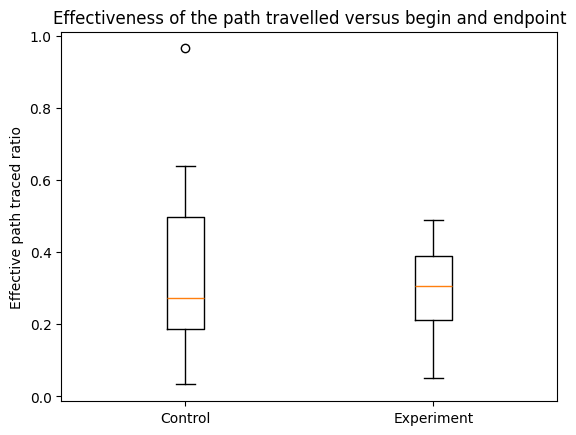

In [66]:
# effective travel: total_distance / distance_begin_and_end

x_keys_control = all_cell_stats["control"].keys()
x_keys_experiment = all_cell_stats["experiment"].keys()

y_control = [all_cell_stats["control"][i]["distance_begin_end"] / all_cell_stats["control"][i]["complete_trajectory_distance"] for i in x_keys_control]
y_experiment = [all_cell_stats["experiment"][i]["distance_begin_end"] / all_cell_stats["experiment"][i]["complete_trajectory_distance"] for i in x_keys_experiment]

data = [y_control, y_experiment]

plt.boxplot(data)
ax = plt.gca()
ax.set_xticklabels(["Control", "Experiment"])
ax.set_ylabel("Effective path traced ratio")
ax.set_title("Effectiveness of the path travelled versus begin and endpoint")


plt.show()

In [ ]:
# dict_keys(['mean_intensity', 'std_dev', 'smoothness', 'uniformity', 'area', 'perimeter', 'roundness', 'distance_begin_end', 'velocity_begin_end', 'complete_trajectory_distance', 'velocity_complete_trajectory'])

def create_tex_tab_stats(all_cell_stats, typing="control"):
	table_begin = "\n".join([r"\begin{table}[h!]",
                   r"\centering",
                   r"""\caption{Computed shape features for the cell such as Area, Perimeter, Roundness; and texture features such as Mean intensity, Standard Deviation on the intensity, Smoothness and Uniformity are calculated for each of the """ +  f"{typing}"  + " cells and averaged out for each of the frames.}",
                   r"\scalebox{0.85}{\begin{tabular}{c|ccccccc}",
                   r"\hline",
                   r"\textbf{Cell} & \textbf{Area} & \textbf{Perimeter} & \textbf{Roundness} & \textbf{Mean Intensity} & \textbf{Stddev Intensity} & \textbf{Smoothness} & \textbf{Uniformity}\\",
                   r"\hline",
                   ""])
	lines = []

	properties = ["area", "perimeter", "roundness", "mean_intensity", "std_dev", "smoothness", "uniformity"]

	for cell in all_cell_stats[typing].keys():
		str_line = f"{cell} & " + " & ".join([f"{round(all_cell_stats[typing][cell][p], ndigits=3)}" for p in properties])

		str_line += r"\\"
		lines.append(str_line)
	str_lines = "\n".join(lines)

	table_end = "\n".join(["", r"\end{tabular}}", r"\label{tab:" + f"{typing}" + "_cell_features}", r"\end{table}"])

	table_str = table_begin + str_lines + table_end
	
	out_file = open(f"{typing}_cell_stats.tex", "w")
	out_file.write(table_str)
	out_file.close()



def create_tex_tab_movement(all_cell_stats, typing="control"):
	table_begin = "\n".join([r"\begin{table}[h!]",
                   r"\centering",
                   r"""\caption{Computed Trajectory and velocity for each of the selected cells in the frames, either with total distance travelled, or difference between begin and endpoint for each of the """ +  f"{typing}"  + " cells.}",
                   r"\scalebox{0.70}{\begin{tabular}{c|cc|cc}",
                   r"\hline",
                   r"\textbf{Cell} & \textbf{Complete trajectory} & \textbf{Velocity ($\text{pixel }s^{-1}$)} & \textbf{Distance begin and endpoint} & \textbf{Effective travel velocity ($\text{pixel }s^{-1}$)}\\",
                   r"\hline",
                   ""])
	lines = []

	properties = ["complete_trajectory_distance", "velocity_complete_trajectory", "distance_begin_end", "velocity_begin_end"]

	for cell in all_cell_stats[typing].keys():
		str_line = f"{cell} & " + " & ".join([f"{round(all_cell_stats[typing][cell][p], ndigits=3)}" for p in properties])

		str_line += r"\\"
		lines.append(str_line)
	str_lines = "\n".join(lines)

	table_end = "\n".join(["", r"\end{tabular}}", r"\label{tab:" + f"{typing}" + "_movement_stats}", r"\end{table}"])

	table_str = table_begin + str_lines + table_end
	
	out_file = open(f"{typing}_movement_stats.tex", "w")
	out_file.write(table_str)
	out_file.close()

def create_tex_tab_correlations(cell_correlations):
	table_begin = "\n".join([r"\begin{table}[h!]",
                   r"\centering",
                   r"""\caption{Pearson Correlations for each of features compared to the speed for the cells globally; and locally for either of the two cell lines based on the 15 chosen cells that were tracked.}""",
                   r"\scalebox{0.70}{\begin{tabular}{c|ccc}",
                   r"\hline",
                   r"\textbf{Feature} & \textbf{Global Correlation} & \textbf{Control-only Correlation} & \textbf{Experiment-only Correlation}\\",
                   r"\hline",
                   ""])
	lines = []
	rename = {"mean_intensity": "Mean Intensity",
		   "std_dev": "Standard Deviation"}


	for feature in cell_correlations["control"].keys():
		a = round(float(cell_correlations["global"][feature]), ndigits=3)
		b = round(float(cell_correlations["control"][feature]), ndigits=3)
		c = round(float(cell_correlations["experiment"][feature]), ndigits=3)

		str_line = f"{rename.get(feature, feature).capitalize()} & {a} & {b} & {c}"

		str_line += r"\\"
		lines.append(str_line)
	str_lines = "\n".join(lines)

	table_end = "\n".join(["", r"\end{tabular}}", r"\label{tab:correlations}", r"\end{table}"])

	table_str = table_begin + str_lines + table_end
	
	out_file = open(f"correlations.tex", "w")
	out_file.write(table_str)
	out_file.close()





In [77]:
create_tex_tab_stats(all_cell_stats, "control")
create_tex_tab_stats(all_cell_stats, "experiment")
create_tex_tab_movement(all_cell_stats, "control")
create_tex_tab_movement(all_cell_stats, "experiment")

In [84]:
create_tex_tab_correlations(all_correlations)